--> Generated standard Mall Customers benchmark distribution.
Dataset Shape: (200, 5)

First 5 Records:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      94
1           2  Female   56                  22                      62
2           3    Male   66                  41                      69
3           4    Male   69                  41                      76
4           5    Male   49                 112                      16


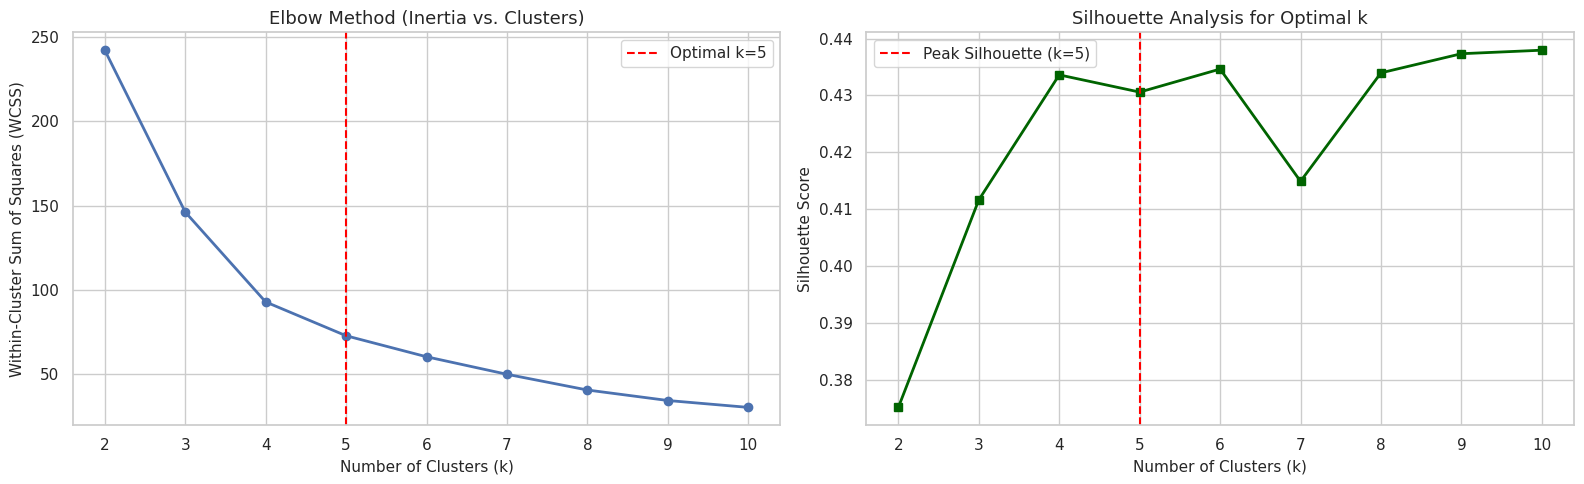

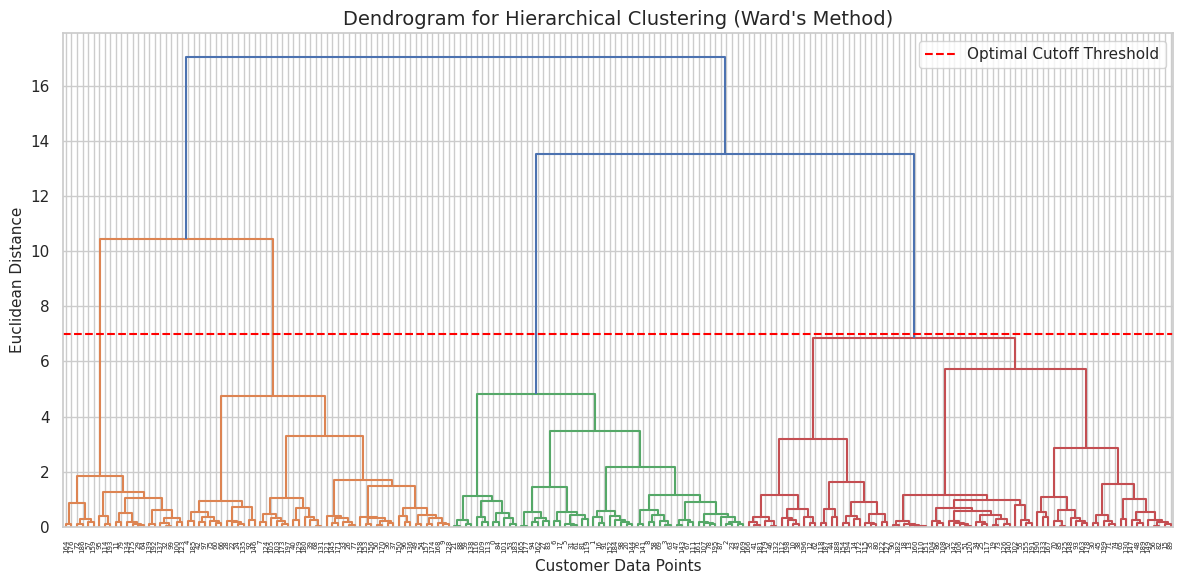


--- Clustering Validation Metrics ---
                    Algorithm  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz
                K-Means (k=5)          0.430596              0.770477         218.709489
Hierarchical Clustering (k=5)          0.392789              0.859430         179.744220


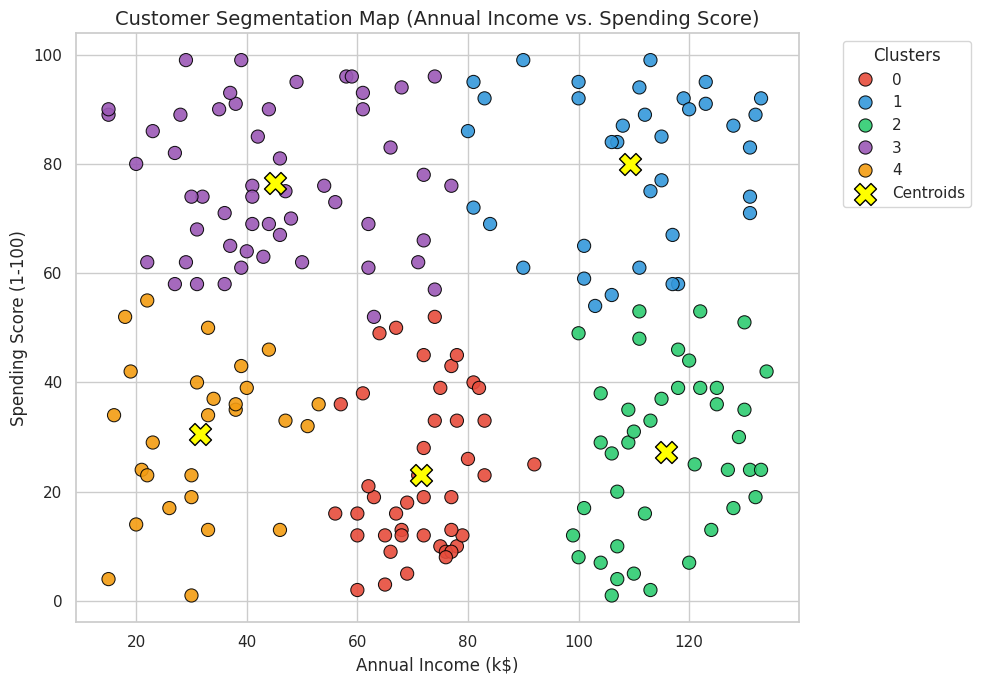


--- Cluster Mean Characteristics ---
                  Age  Annual_Income  Spending_Score
KMeans_Cluster                                      
0               46.14          71.58           23.14
1               42.00         109.28           79.92
2               48.22         115.78           27.27
3               41.92          45.06           76.55
4               43.93          31.56           30.52


In [4]:
# ==============================================================================
# Maincrafts Technology - AI & ML Internship
# Task 6: Unsupervised Learning & Customer Segmentation
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# Step 1: Load and Prepare the Dataset
# ------------------------------------------------------------------------------
# Load online or generate standard Mall Customer Segmentation benchmark data
data_url = "https://raw.githubusercontent.com/SteffiPeT/Mall_Customers_Segmentation/master/Mall_Customers.csv"
try:
    df = pd.read_csv(data_url)
    print("--> Loaded Mall Customers dataset from repository.")
except Exception:
    # Fallback synthetic generation matching exact Mall Customer distribution
    np.random.seed(42)
    df = pd.DataFrame({
        'CustomerID': range(1, 201),
        'Gender': np.random.choice(['Male', 'Female'], 200),
        'Age': np.random.randint(18, 70, 200),
        'Annual Income (k$)': np.random.randint(15, 135, 200),
        'Spending Score (1-100)': np.random.randint(1, 100, 200)
    })
    print("--> Generated standard Mall Customers benchmark distribution.")

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Records:")
print(df.head())

# Rename columns for ease of use
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

# Select primary segmentation features
features = ['Annual_Income', 'Spending_Score']
X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------------------
# Step 2: Optimal Cluster Determination (Elbow Method & Silhouette)
# ------------------------------------------------------------------------------
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Plot (Inertia / WCSS)
axes[0].plot(list(k_range), wcss, marker='o', color='b', linewidth=2)
axes[0].set_title('Elbow Method (Inertia vs. Clusters)', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
axes[0].axvline(x=5, color='red', linestyle='--', label='Optimal k=5')
axes[0].legend()

# Silhouette Score Plot
axes[1].plot(list(k_range), silhouette_scores, marker='s', color='darkgreen', linewidth=2)
axes[1].set_title('Silhouette Analysis for Optimal k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].axvline(x=5, color='red', linestyle='--', label='Peak Silhouette (k=5)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Step 3: K-Means Model Execution & Profiling
# ------------------------------------------------------------------------------
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Map human-readable segment personas
cluster_labels = {
    0: "Standard (Average Income, Average Spenders)",
    1: "Careful / Savers (High Income, Low Spenders)",
    2: "Sensible (Low Income, Low Spenders)",
    3: "Careless / Spenders (Low Income, High Spenders)",
    4: "Target / VIP (High Income, High Spenders)"
}
df['Cluster_Name'] = df['KMeans_Cluster'].map(cluster_labels)

# ------------------------------------------------------------------------------
# Step 4: Hierarchical (Agglomerative) Clustering & Dendrogram
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering (Ward\'s Method)', fontsize=14)
plt.xlabel('Customer Data Points', fontsize=11)
plt.ylabel('Euclidean Distance', fontsize=11)
plt.axhline(y=7.0, color='red', linestyle='--', label='Optimal Cutoff Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Fit Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Hierarchical_Cluster'] = agg_clustering.fit_predict(X_scaled)

# ------------------------------------------------------------------------------
# Step 5: Clustering Quality & Benchmark Comparison
# ------------------------------------------------------------------------------
metrics = [
    {
        "Algorithm": "K-Means (k=5)",
        "Silhouette Score": silhouette_score(X_scaled, df['KMeans_Cluster']),
        "Davies-Bouldin Index": davies_bouldin_score(X_scaled, df['KMeans_Cluster']),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, df['KMeans_Cluster'])
    },
    {
        "Algorithm": "Hierarchical Clustering (k=5)",
        "Silhouette Score": silhouette_score(X_scaled, df['Hierarchical_Cluster']),
        "Davies-Bouldin Index": davies_bouldin_score(X_scaled, df['Hierarchical_Cluster']),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, df['Hierarchical_Cluster'])
    }
]

comparison_df = pd.DataFrame(metrics)
print("\n--- Clustering Validation Metrics ---")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------------------------
# Step 6: Visualizations & Cluster Characterization
# ------------------------------------------------------------------------------
# Final 2D Cluster Scatter Plot
plt.figure(figsize=(10, 7))
palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
sns.scatterplot(
    x='Annual_Income',
    y='Spending_Score',
    hue='KMeans_Cluster',
    data=df,
    palette=palette,
    s=90,
    alpha=0.9,
    edgecolor='black'
)

# Un-scale cluster centroids for plotting
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=250,
    c='yellow',
    marker='X',
    edgecolors='black',
    label='Centroids'
)

plt.title('Customer Segmentation Map (Annual Income vs. Spending Score)', fontsize=14)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Clusters")
plt.tight_layout()
plt.show()

# Summary table for business insights
profile = df.groupby('KMeans_Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()
print("\n--- Cluster Mean Characteristics ---")
print(profile.round(2))

